In [ ]:
# DA ESEGUIRE SU COLAB NEL DRIVE DEVONO ESSERCI LE CARTELLE ZIPPATE: SINOGRAMS FBP VALIDATION_RESIZED

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

SINOGRAMS_ZIP = "/content/drive/MyDrive/sinograms.zip"
FBP_ZIP = "/content/drive/MyDrive/fbp.zip"
# Zippa SOLO la cartella validation_resized (senza cartella genitore attorno),
# chiamala validation_resized.zip e caricala nella home del tuo Drive.
VALIDATION_RESIZED_ZIP = "/content/drive/MyDrive/validation_resized.zip"

LOCAL_SINOGRAMS_DIR = Path("/content/sinograms")
LOCAL_FBP_DIR = Path("/content/fbp")
VALIDATION_DIR = Path("/content/validation_resized")

if not LOCAL_SINOGRAMS_DIR.exists():
    print("Estraggo i sinogrammi...")
    get_ipython().system('unzip -q "{SINOGRAMS_ZIP}" -d /content/')
else:
    print("Sinogrammi gia' estratti, salto.")

if not LOCAL_FBP_DIR.exists():
    print("Estraggo FBP...")
    get_ipython().system('unzip -q "{FBP_ZIP}" -d /content/')
else:
    print("FBP gia' estratto, salto.")

if not VALIDATION_DIR.exists():
    print("Estraggo validation_resized (ground truth)...")
    get_ipython().system('unzip -q "{VALIDATION_RESIZED_ZIP}" -d /content/')
else:
    print("validation_resized gia' estratto, salto.")

assert VALIDATION_DIR.exists(), (
    f"Non trovo {VALIDATION_DIR} -- controlla che lo zip contenga le cartelle paziente "
    f"direttamente alla radice (non dentro un'altra cartella dataset_resized/)."
)


Mounted at /content/drive
Estraggo i sinogrammi...
Estraggo FBP...
Estraggo validation_resized (ground truth)...


In [2]:
# ============================================================
# Installazione IPPy + patch del bug CuPy (stessa patch delle altre volte)
# ============================================================
get_ipython().system('pip install -q git+https://github.com/devangelista2/IPPy.git')
try:
    get_ipython().system('pip install -q cupy-cuda12x')
    import cupy  # noqa: F401
    print("CuPy installato correttamente.")
except Exception as e:
    print(f"CuPy non disponibile ({e}).")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 8.1 MB/s eta 0:00:00
CuPy installato correttamente.


In [3]:
import re, glob

candidates = glob.glob("/usr/**/dist-packages/IPPy/operators.py", recursive=True) + \
             glob.glob("/usr/**/site-packages/IPPy/operators.py", recursive=True)
assert candidates, "Non trovo operators.py di IPPy installato."
operators_path = candidates[0]

with open(operators_path) as f:
    src = f.read()

pattern = re.compile(
    r'(elif torch\.cuda\.is_available\(\) and not force_cpu:\s*\n'
    r'\s*warnings\.warn\(\s*\n'
    r'\s*"CUDA available but CuPy not found\. CTProjector limited to CPU operations for ASTRA data transfer\."\s*\n'
    r'\s*\)\s*\n'
    r'\s*# Force CPU mode if CuPy isn\'t there for GPU data handling\s*\n'
    r'(\s*)self\.use_gpu = False)'
)

def _fix(m):
    indent = m.group(2)
    return (
        "elif torch.cuda.is_available() and not force_cpu:\n"
        f"{indent}try:\n"
        f"{indent}    import cupy  # noqa: F401\n"
        f"{indent}except ImportError:\n"
        f"{indent}    warnings.warn(\n"
        f'{indent}        "CUDA available but CuPy not found. CTProjector limited to CPU operations for ASTRA data transfer."\n'
        f"{indent}    )\n"
        f"{indent}    self.use_gpu = False\n"
    )

new_src, n = pattern.subn(_fix, src)
if n == 1:
    with open(operators_path, "w") as f:
        f.write(new_src)
    print(f"Patch applicata a {operators_path}")
elif "import cupy  # noqa: F401" in src:
    print("Patch gia' presente, salto.")
else:
    raise RuntimeError(f"Blocco da patchare non trovato in {operators_path}.")

Patch applicata a /usr/local/lib/python3.13/dist-packages/IPPy/operators.py


In [5]:

import numpy as np
from skimage import io

#Funzione di normalizzazione in [0,1]
def load_normalized_image(path: Path):
    image = io.imread(path)
    return image.astype(np.float32) / 255.0

In [6]:
import math
import time
import json

import torch
from tqdm.auto import tqdm

from IPPy import operators
from IPPy.solvers import ChambollePockTpVConstrained
from IPPy.utilities import metrics
from IPPy.utilities.metrics import PSNR, SSIM
from IPPy.nn.models import UNet

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo in uso: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# NOTA: CTProjector di IPPy non ha implementato il path GPU per i tensori PyTorch
# (matvec/adjoint sono TODO non finiti) -- l'accelerazione vera arriva da ASTRA
# internamente; i tensori che passano per K(x)/K.T(y)/il solver restano su CPU
# per tutto il notebook. Solo la UNet gira esplicitamente su DEVICE.

Dispositivo in uso: cuda
GPU: NVIDIA L4


In [7]:
# ============================================================
# Parametri, griglia di tuning e proiettori
# ============================================================
IMG_SIZE = (256, 256)
NOISE_LEVEL = 0.005
TUNING_MAXITER = 150   # meta' del maxiter di generazione (300): sufficiente per un confronto relativo

ANGLE_CONFIGS = {
    90: np.linspace(-45, 45, 90),
    45: np.linspace(-45, 45, 45),
    30: np.linspace(-30, 30, 32)[1:-1],
    15: np.linspace(-30, 30, 17)[1:-1],
}

N_VAL_SAMPLES = 12   # stesso numero usato nel tuning di TV

LAMBDA_CANDIDATES = [0.01, 0.03, 0.05, 0.1, 0.2]
ETA_CANDIDATES = [1e-3, 2e-3, 5e-3, 1e-2]
P_CANDIDATES = [0.1, 0.3, 0.5]

PSNR_WEIGHT = 0.5   # peso di PSNR nello score combinato (1-PSNR_WEIGHT per SSIM)

PROJECTORS = {
    n_angles: operators.CTProjector(
        img_shape=IMG_SIZE,
        angles=np.deg2rad(angles),
        geometry="parallel",
        force_cpu=False,   # ASTRA usa comunque il proiettore CUDA internamente
    )
    for n_angles, angles in ANGLE_CONFIGS.items()
}

print(f"Combinazioni per configurazione: {len(LAMBDA_CANDIDATES) * len(ETA_CANDIDATES) * len(P_CANDIDATES)}")
print(f"Solve totali stimati: {len(LAMBDA_CANDIDATES) * len(ETA_CANDIDATES) * len(P_CANDIDATES) * len(ANGLE_CONFIGS) * N_VAL_SAMPLES}")

Attempting to create ASTRA projector type: 'cuda' for 'parallel' geometry...
Successfully created ASTRA projector type: 'cuda'
CTProjector initialized. Geometry: parallel. Using GPU: True. FBP Algorithm: FBP_CUDA
Attempting to create ASTRA projector type: 'cuda' for 'parallel' geometry...
Successfully created ASTRA projector type: 'cuda'
CTProjector initialized. Geometry: parallel. Using GPU: True. FBP Algorithm: FBP_CUDA
Attempting to create ASTRA projector type: 'cuda' for 'parallel' geometry...
Successfully created ASTRA projector type: 'cuda'
CTProjector initialized. Geometry: parallel. Using GPU: True. FBP Algorithm: FBP_CUDA
Attempting to create ASTRA projector type: 'cuda' for 'parallel' geometry...
Successfully created ASTRA projector type: 'cuda'
CTProjector initialized. Geometry: parallel. Using GPU: True. FBP Algorithm: FBP_CUDA
Combinazioni per configurazione: 60
Solve totali stimati: 2880


In [8]:
# ============================================================
# Caricamento dei 4 modelli UNet dai checkpoint su Drive
# ============================================================
UNET_CHECKPOINTS_DIR = Path("/content/drive/MyDrive/unet_checkpoints")


def infer_unet_config(state_dict):
    ch_in = state_dict["preprocess.conv.0.weight"].shape[1]
    middle_ch = [state_dict["preprocess.conv.0.weight"].shape[0]]

    i = 0
    while f"encoder_layers.{i}.conv.conv2.weight" in state_dict:
        middle_ch.append(state_dict[f"encoder_layers.{i}.conv.conv2.weight"].shape[0])
        i += 1
    n_blocks = i

    ch_out = state_dict["postprocess.weight"].shape[0]

    return {
        "ch_in": ch_in,
        "ch_out": ch_out,
        "middle_ch": middle_ch,
        "n_layers_per_block": 2,
        "down_layers": tuple(["ResDownBlock"] * n_blocks),
        "up_layers": tuple(["ResUpBlock"] * n_blocks),
        "final_activation": "sigmoid",
    }


def load_unet_model(n_angles: int) -> torch.nn.Module:
    weights_path = UNET_CHECKPOINTS_DIR / str(n_angles) / "model_weights.pth"
    state_dict = torch.load(weights_path, map_location=DEVICE)
    config = infer_unet_config(state_dict)
    print(f"{n_angles} angoli -> {config}")

    model = UNet(**config)
    model.load_state_dict(state_dict)
    model.to(DEVICE)
    model.eval()
    return model


models = {n_angles: load_unet_model(n_angles) for n_angles in ANGLE_CONFIGS}

90 angoli -> {'ch_in': 1, 'ch_out': 1, 'middle_ch': [32, 64, 128, 256], 'n_layers_per_block': 2, 'down_layers': ('ResDownBlock', 'ResDownBlock', 'ResDownBlock'), 'up_layers': ('ResUpBlock', 'ResUpBlock', 'ResUpBlock'), 'final_activation': 'sigmoid'}
45 angoli -> {'ch_in': 1, 'ch_out': 1, 'middle_ch': [32, 64, 128, 256], 'n_layers_per_block': 2, 'down_layers': ('ResDownBlock', 'ResDownBlock', 'ResDownBlock'), 'up_layers': ('ResUpBlock', 'ResUpBlock', 'ResUpBlock'), 'final_activation': 'sigmoid'}
30 angoli -> {'ch_in': 1, 'ch_out': 1, 'middle_ch': [32, 64, 128, 256], 'n_layers_per_block': 2, 'down_layers': ('ResDownBlock', 'ResDownBlock', 'ResDownBlock'), 'up_layers': ('ResUpBlock', 'ResUpBlock', 'ResUpBlock'), 'final_activation': 'sigmoid'}
15 angoli -> {'ch_in': 1, 'ch_out': 1, 'middle_ch': [32, 64, 128, 256], 'n_layers_per_block': 2, 'down_layers': ('ResDownBlock', 'ResDownBlock', 'ResDownBlock'), 'up_layers': ('ResUpBlock', 'ResUpBlock', 'ResUpBlock'), 'final_activation': 'sigmoid'}


In [9]:
# ============================================================
# Solver Weighted TV (stessa sottoclasse usata nella generazione)
# ============================================================

class ChambollePockWeightedTpVConstrained(ChambollePockTpVConstrained):

    def __call__(
        self,
        y_delta,
        epsilon,
        lmbda,
        x_tilde,
        x_true=None,
        starting_point=None,
        eta=2e-3,
        maxiter=100,
        p=0.3,
        verbose=False,
        *args,
        **kwargs,
    ):
        assert x_tilde is not None, "x_tilde (es. output UNet) e' obbligatorio per la Weighted TV."

        nu = math.sqrt(
            self.power_method(self.K, num_iterations=10)
            / self.power_method(self.grad, num_iterations=10)
        )
        Gamma = math.sqrt(
            self.power_method_dual_operator(self.K, self.grad, num_iterations=10)
        )
        tau = 1 / Gamma
        sigma = 1 / Gamma
        theta = 1

        k = 0
        x = torch.zeros((1, 1, self.nx, self.ny), device=y_delta.device) if starting_point is None else starting_point
        y = torch.zeros((1, 1, self.mx, self.my), device=y_delta.device)
        w = torch.zeros((1, 2, self.nx, self.ny), device=y_delta.device)
        xx = x

        grad_x_tilde = self.grad(x_tilde)
        grad_mag_tilde = torch.square(grad_x_tilde[:, 0:1]) + torch.square(grad_x_tilde[:, 1:2])
        W = (torch.sqrt(eta**2 + grad_mag_tilde) / eta) ** (p - 1)
        WW = torch.cat((W, W), dim=1)

        info = dict()
        info["residues"] = torch.zeros((maxiter + 1, 1))
        info["obj"] = torch.zeros((maxiter + 1, 1))
        info["RE"] = torch.zeros((maxiter + 1, 1))
        info["RMSE"] = torch.zeros((maxiter + 1, 1))
        info["PSNR"] = torch.zeros((maxiter + 1, 1))
        info["SSIM"] = torch.zeros((maxiter + 1, 1))
        info["iterations"] = 0

        con = True
        while con and (k < maxiter):
            yy = y + sigma * (self.K(xx) - y_delta)
            y = max(torch.norm(yy) - (sigma * epsilon), 0) * yy / torch.norm(yy)

            x_grad = self.grad(xx)
            ww = w + sigma * nu * x_grad
            abs_ww = torch.square(ww[:, 0:1]) + torch.square(ww[:, 1:2])
            abs_ww = torch.cat((abs_ww, abs_ww), dim=1)

            lmbda_vec_over_nu = lmbda * WW / nu
            w = lmbda_vec_over_nu * ww / torch.maximum(lmbda_vec_over_nu, abs_ww)

            xtmp = x
            x = xtmp - tau * (self.K.T(y) + nu * self.grad.T(w))
            x[x < 0] = 0
            xx = x + theta * (x - xtmp)

            if x_true is not None:
                info["RE"][k] = metrics.RE(x, x_true)
                info["PSNR"][k] = metrics.PSNR(x, x_true)
                info["RMSE"][k] = metrics.RMSE(x, x_true)
                info["SSIM"][k] = metrics.SSIM(x, x_true)

            grad_x = self.grad(x)
            grad_mag = torch.sqrt(torch.square(grad_x[:, 0:1]) + torch.square(grad_x[:, 1:2]))
            ftpv = torch.sum(torch.abs(W * grad_mag))
            res = torch.norm(self.K(x) - y_delta, 2) ** 2

            info["residues"][k] = res
            info["obj"][k] = 0.5 * res + lmbda * ftpv

            c = math.sqrt(res) / (torch.max(y_delta) * math.sqrt(self.mx * self.my))
            d_abs = torch.norm(x.flatten() - xtmp.flatten())

            if (c >= 9e-6) and (c <= 1.1e-5):
                con = False
            if d_abs < 1e-3 * (1 + torch.norm(xtmp.flatten())):
                con = False

            k = k + 1

        info["residues"] = info["residues"][:k]
        info["obj"] = info["obj"][:k]
        info["RE"] = info["RE"][:k]
        info["RMSE"] = info["RMSE"][:k]
        info["PSNR"] = info["PSNR"][:k]
        info["SSIM"] = info["SSIM"][:k]
        info["iterations"] = k
        return x, info

In [10]:
# ============================================================
# Pre-caricamento e cache dei dati di validation (12 campioni per
# configurazione): sinogramma, x_true (GT), epsilon, x_tilde (UNet).
# x_tilde non dipende da lambda/eta/p, quindi si calcola una volta
# sola qui e si riusa per tutta la griglia.
# ============================================================

cached_data = {}   # n_angles -> lista di (y_delta, x_true, epsilon, x_tilde)

for n_angles in ANGLE_CONFIGS:
    sino_dir = LOCAL_SINOGRAMS_DIR / "validation" / str(n_angles)
    fbp_dir = LOCAL_FBP_DIR / "validation" / str(n_angles)
    model = models[n_angles]

    sino_paths = sorted(sino_dir.rglob("*.npy"))[:N_VAL_SAMPLES]

    samples = []
    for sino_path in tqdm(sino_paths, desc=f"Cache [{n_angles} angoli]"):
        rel_path = sino_path.relative_to(sino_dir)
        gt_path = (VALIDATION_DIR / rel_path).with_suffix(".png")
        fbp_path = fbp_dir / rel_path

        sinogram = np.load(sino_path)
        y_delta = torch.from_numpy(sinogram).float().unsqueeze(0).unsqueeze(0)   # CPU
        epsilon = NOISE_LEVEL * torch.norm(y_delta)

        gt = load_normalized_image(gt_path)
        x_true = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0)   # CPU

        fbp = np.clip(np.load(fbp_path).astype(np.float32), 0.0, 1.0)
        fbp_t = torch.from_numpy(fbp).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            x_tilde = model(fbp_t).cpu()   # UNet su GPU, poi CPU per il solver

        samples.append((y_delta, x_true, epsilon, x_tilde))

    cached_data[n_angles] = samples

print("Cache completata per tutte le configurazioni.")

Cache [90 angoli]:   0%|          | 0/12 [00:00<?, ?it/s]

Cache [45 angoli]:   0%|          | 0/12 [00:00<?, ?it/s]

Cache [30 angoli]:   0%|          | 0/12 [00:00<?, ?it/s]

Cache [15 angoli]:   0%|          | 0/12 [00:00<?, ?it/s]

Cache completata per tutte le configurazioni.


In [11]:
# ============================================================
# Test rapido su UNA combinazione: stima il tempo totale della griglia
# ============================================================

test_n_angles = 90
solver = ChambollePockWeightedTpVConstrained(PROJECTORS[test_n_angles])
y_delta, x_true, epsilon, x_tilde = cached_data[test_n_angles][0]

t0 = time.time()
with torch.no_grad():
    _, info = solver(
        y_delta, epsilon=epsilon, lmbda=LAMBDA_CANDIDATES[0], x_tilde=x_tilde,
        x_true=x_true, starting_point=torch.zeros_like(x_true),
        eta=ETA_CANDIDATES[0], maxiter=TUNING_MAXITER, p=P_CANDIDATES[0], verbose=False,
    )
elapsed = time.time() - t0

n_combos = len(LAMBDA_CANDIDATES) * len(ETA_CANDIDATES) * len(P_CANDIDATES)
n_solve_totali = n_combos * len(ANGLE_CONFIGS) * N_VAL_SAMPLES

print(f"Tempo per un solve ({TUNING_MAXITER} iter max): {elapsed:.2f} s")
print(f"Iterazioni effettive: {info['iterations']} / {TUNING_MAXITER}")
print(f"Stima tempo totale griglia ({n_solve_totali} solve): {elapsed * n_solve_totali / 60:.1f} minuti")

Tempo per un solve (150 iter max): 1.62 s
Iterazioni effettive: 150 / 150
Stima tempo totale griglia (2880 solve): 77.7 minuti


In [12]:
# ============================================================
# GRID SEARCH: lambda x eta x p, per ciascuna configurazione angolare
# ============================================================

grid_results = {}   # n_angles -> lista di dict {lambda, eta, p, psnr, ssim}

for n_angles in ANGLE_CONFIGS:
    print(f"\n=== Tuning per {n_angles} angoli ===")
    solver = ChambollePockWeightedTpVConstrained(PROJECTORS[n_angles])
    samples = cached_data[n_angles]

    results = []
    combos = [(l, e, p) for l in LAMBDA_CANDIDATES for e in ETA_CANDIDATES for p in P_CANDIDATES]

    for lmbda, eta, p in tqdm(combos, desc=f"[{n_angles} angoli] griglia"):
        psnr_list, ssim_list = [], []

        for y_delta, x_true, epsilon, x_tilde in samples:
            with torch.no_grad():
                _, info = solver(
                    y_delta, epsilon=epsilon, lmbda=lmbda, x_tilde=x_tilde,
                    x_true=x_true, starting_point=torch.zeros_like(x_true),
                    eta=eta, maxiter=TUNING_MAXITER, p=p, verbose=False,
                )
            psnr_list.append(info["PSNR"][-1].item())
            ssim_list.append(info["SSIM"][-1].item())

        results.append({
            "lambda": lmbda, "eta": eta, "p": p,
            "psnr": float(np.mean(psnr_list)), "ssim": float(np.mean(ssim_list)),
        })

    grid_results[n_angles] = results
    print(f"Completato: {len(results)} combinazioni testate per {n_angles} angoli.")


=== Tuning per 90 angoli ===


[90 angoli] griglia:   0%|          | 0/60 [00:00<?, ?it/s]

Completato: 60 combinazioni testate per 90 angoli.

=== Tuning per 45 angoli ===


[45 angoli] griglia:   0%|          | 0/60 [00:00<?, ?it/s]

Completato: 60 combinazioni testate per 45 angoli.

=== Tuning per 30 angoli ===


[30 angoli] griglia:   0%|          | 0/60 [00:00<?, ?it/s]

Completato: 60 combinazioni testate per 30 angoli.

=== Tuning per 15 angoli ===


[15 angoli] griglia:   0%|          | 0/60 [00:00<?, ?it/s]

Completato: 60 combinazioni testate per 15 angoli.


In [13]:
# ============================================================
# Selezione della combinazione migliore per configurazione (score
# combinato PSNR+SSIM, normalizzati in [0,1], stesso schema di
# 03_TV_hyperparametertuning.ipynb) + salvataggio su Drive
# ============================================================

best_params_per_config = {}

for n_angles, results in grid_results.items():
    psnr_values = np.array([r["psnr"] for r in results])
    ssim_values = np.array([r["ssim"] for r in results])

    psnr_norm = (psnr_values - psnr_values.min()) / (psnr_values.max() - psnr_values.min() + 1e-12)
    ssim_norm = (ssim_values - ssim_values.min()) / (ssim_values.max() - ssim_values.min() + 1e-12)
    combined = PSNR_WEIGHT * psnr_norm + (1 - PSNR_WEIGHT) * ssim_norm

    order = np.argsort(-combined)   # indici ordinati dal migliore al peggiore

    print(f"\n=== {n_angles} angoli -- top 5 combinazioni ===")
    for idx in order[:5]:
        r = results[idx]
        print(f"  lambda={r['lambda']:<6} eta={r['eta']:<8} p={r['p']:<4} "
              f"-> PSNR={r['psnr']:.2f} dB  SSIM={r['ssim']:.4f}  score={combined[idx]:.4f}")

    best_idx = int(order[0])
    best_params_per_config[n_angles] = results[best_idx]

print("\n=== Riepilogo: parametri scelti per configurazione ===")
for n_angles, params in best_params_per_config.items():
    print(f"{n_angles} angoli -> lambda={params['lambda']}, eta={params['eta']}, p={params['p']}")

TUNING_DIR = Path("/content/drive/MyDrive/weighted_tv_tuning")
TUNING_DIR.mkdir(parents=True, exist_ok=True)

with open(TUNING_DIR / "best_params_wtv.json", "w") as f:
    json.dump(best_params_per_config, f, indent=2)

with open(TUNING_DIR / "full_grid_results_wtv.json", "w") as f:
    json.dump(grid_results, f, indent=2)

print(f"\nSalvato in: {TUNING_DIR}")


=== 90 angoli -- top 5 combinazioni ===
  lambda=0.2    eta=0.002    p=0.1  -> PSNR=22.14 dB  SSIM=0.6691  score=0.9953
  lambda=0.2    eta=0.005    p=0.1  -> PSNR=22.15 dB  SSIM=0.6681  score=0.9703
  lambda=0.1    eta=0.005    p=0.1  -> PSNR=22.12 dB  SSIM=0.6684  score=0.9504
  lambda=0.2    eta=0.001    p=0.1  -> PSNR=22.10 dB  SSIM=0.6689  score=0.9469
  lambda=0.2    eta=0.002    p=0.3  -> PSNR=22.14 dB  SSIM=0.6675  score=0.9402

=== 45 angoli -- top 5 combinazioni ===
  lambda=0.2    eta=0.005    p=0.1  -> PSNR=22.31 dB  SSIM=0.6690  score=0.9669
  lambda=0.1    eta=0.005    p=0.1  -> PSNR=22.24 dB  SSIM=0.6704  score=0.9518
  lambda=0.2    eta=0.002    p=0.1  -> PSNR=22.26 dB  SSIM=0.6697  score=0.9461
  lambda=0.1    eta=0.01     p=0.1  -> PSNR=22.25 dB  SSIM=0.6689  score=0.9238
  lambda=0.2    eta=0.002    p=0.3  -> PSNR=22.26 dB  SSIM=0.6684  score=0.9191

=== 30 angoli -- top 5 combinazioni ===
  lambda=0.03   eta=0.001    p=0.5  -> PSNR=19.84 dB  SSIM=0.5676  score=0.98

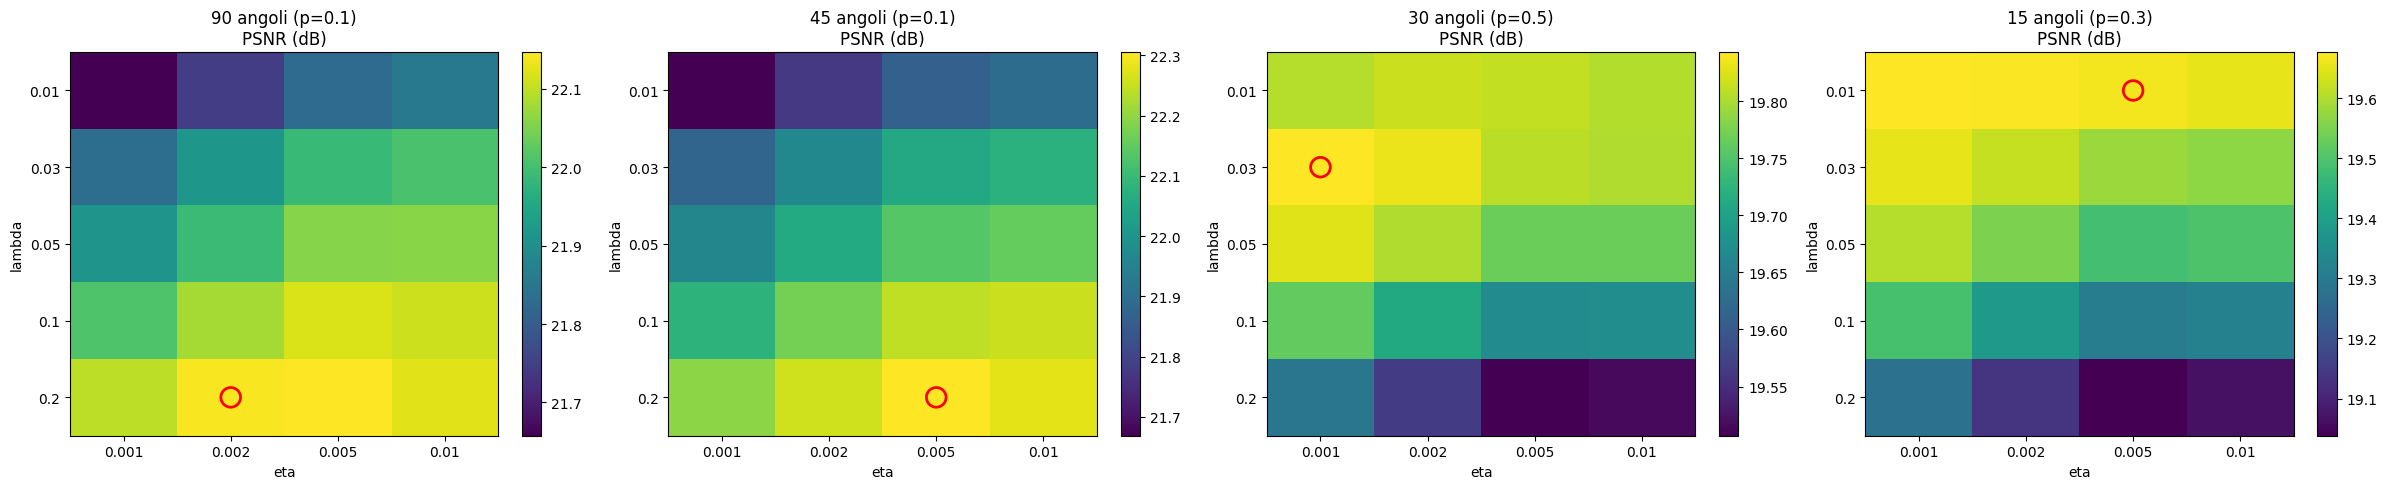

In [14]:
# ============================================================
# Heatmap lambda x eta (alla p migliore) per ciascuna configurazione
# ============================================================
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, len(ANGLE_CONFIGS), figsize=(6 * len(ANGLE_CONFIGS), 5))

for ax, (n_angles, results) in zip(axs, grid_results.items()):
    best_p = best_params_per_config[n_angles]["p"]

    grid = np.full((len(LAMBDA_CANDIDATES), len(ETA_CANDIDATES)), np.nan)
    for r in results:
        if r["p"] != best_p:
            continue
        i = LAMBDA_CANDIDATES.index(r["lambda"])
        j = ETA_CANDIDATES.index(r["eta"])
        grid[i, j] = r["psnr"]

    im = ax.imshow(grid, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(ETA_CANDIDATES)))
    ax.set_xticklabels(ETA_CANDIDATES)
    ax.set_yticks(range(len(LAMBDA_CANDIDATES)))
    ax.set_yticklabels(LAMBDA_CANDIDATES)
    ax.set_xlabel("eta")
    ax.set_ylabel("lambda")
    ax.set_title(f"{n_angles} angoli (p={best_p})\nPSNR (dB)")
    plt.colorbar(im, ax=ax, fraction=0.046)

    best = best_params_per_config[n_angles]
    bi = LAMBDA_CANDIDATES.index(best["lambda"])
    bj = ETA_CANDIDATES.index(best["eta"])
    ax.scatter(bj, bi, s=200, facecolors="none", edgecolors="red", linewidths=2)

plt.tight_layout()
plt.savefig(TUNING_DIR / "heatmap_lambda_eta_wtv.png", dpi=150)
plt.show()